<a href="https://www.kaggle.com/code/sonawanelalitsunil/online-shopping-trends-sales-analysis-svm-60-98?scriptVersionId=224559777" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/online-shopping-dataset/Online Shopping Data.csv


## Title:
## "Online Shopping Trends & Sales Analysis Dataset"

## Detailed Description:
This dataset captures key insights into online shopping behaviors, sales performance, and customer preferences. It is designed to help businesses and data analysts understand consumer purchasing patterns, optimize marketing strategies, and improve e-commerce operations.

## The dataset includes the following key attributes:

Order ID: Unique identifier for each transaction.

Customer ID: Anonymized unique customer identifier.

Product Name: The name of the purchased item.

Category: The product category (e.g., Electronics, Fashion, Home & Kitchen).

Price (INR/USD/etc.): The cost of the product at the time of purchase.

Quantity Sold: Number of units purchased per order.

Total Sales (INR/USD/etc.): The revenue generated per transaction.

Order Date: Timestamp of the order placement.

Payment Method: Mode of payment used (Credit Card, Debit Card, UPI, COD, etc.).

Customer Rating: Rating given by the customer (1-5 stars).

## Potential Use Cases:

Sales Trend Analysis: Identify seasonal trends in online shopping.

Customer Segmentation: Understand different customer buying behaviors.

Product Demand Forecasting: Predict future sales for better inventory management.

Marketing Strategy Optimization: Analyze the impact of promotions and discounts.

Payment Preferences Insights: Evaluate the most popular payment methods among customers.

## Import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
df = pd.read_csv("/kaggle/input/online-shopping-dataset/Online Shopping Data.csv")

In [4]:
df.head()

,Gender,Online_Shopping_Freq,Online_Purchase_Proportion,Review_Check_Freq,Attraction_Factor,Retailer_Choice_Factors,Preferred_Payment,Local_vs_Intl_Retailers,Preferred_Marketplace,Security_Concern_Level,Promo_Participation,Price_Sensitivity,Comfortable_Price_Range,Frequent_Products,Major_Drawback,Authenticity_Concern,Desired_Improvements
0,Male,Rarely or Never,0-20 %,Always,Ease and Comfort of shopping from home,Brand reputation and trustworthiness,Credit or debit card,"No preference, depends on the product",Daraz,Very concerned,Occasionally participate,Moderately price-sensitive,1k to 5k,Clothing and fashion accessories,"Yes, issues with product quality",Neutral or unsure,Enhanced customer reviews and ratings system
1,Female,Rarely or Never,0-20 %,Always,Attractive discounts and promotions,Product reviews and ratings,Cash on delivery (if available),"No preference, depends on the product",Others,Neutral,Rarely or Never participate,Slightly price-sensitive,1k to 5k,Clothing and fashion accessories,"No, I have not experienced any drawbacks",Neutral or unsure,Enhanced customer reviews and ratings system
2,Female,Once in a month,41-60 %,Always,Ease and Comfort of shopping from home,Brand reputation and trustworthiness,Cash on delivery (if available),"No preference, depends on the product",Daraz,Somewhat concerned,Frequently participate,Moderately price-sensitive,1k to 5k,Clothing and fashion accessories,"Yes, issues with product quality","Yes, always confident in product authenticity ...","Better product descriptions and images, Enhanc..."
3,Male,Once in a month,41-60 %,Always,Ease and Comfort of shopping from home,Product reviews and ratings,Cash on delivery (if available),Prefer local retailers,AliExpress,Somewhat concerned,Rarely or Never participate,Moderately price-sensitive,1k to 5k,Clothing and fashion accessories,"No, I have not experienced any drawbacks",Neutral or unsure,Better product descriptions and images
4,Female,Rarely or Never,0-20 %,Frequently,Ease and Comfort of shopping from home,Brand reputation and trustworthiness,Cash on delivery (if available),"No preference, depends on the product",Amazon,Very concerned,Rarely or Never participate,Moderately price-sensitive,less than 1k,"Books and media (e.g., movies, music)","Yes, issues with product quality","No, often concerned about product authenticity...","Better product descriptions and images, Improv..."


In [5]:
df.tail()

,Gender,Online_Shopping_Freq,Online_Purchase_Proportion,Review_Check_Freq,Attraction_Factor,Retailer_Choice_Factors,Preferred_Payment,Local_vs_Intl_Retailers,Preferred_Marketplace,Security_Concern_Level,Promo_Participation,Price_Sensitivity,Comfortable_Price_Range,Frequent_Products,Major_Drawback,Authenticity_Concern,Desired_Improvements
196,Female,Multiple times per week,41-60 %,Occasionally,Attractive discounts and promotions,Product reviews and ratings,Cash on delivery (if available),"No preference, depends on the product",Others,Very concerned,Always take advantage of promotions and discounts,Extremely price-sensitive,1k to 5k,Clothing and fashion accessories,"Yes, delayed or problematic deliveries","Yes, always confident in product authenticity ...",Better product descriptions and images
197,Male,Rarely or Never,21-40 %,Always,Attractive discounts and promotions,Product reviews and ratings,Cash on delivery (if available),"No preference, depends on the product",Daraz,Very concerned,Occasionally participate,Moderately price-sensitive,less than 1k,Clothing and fashion accessories,"Yes, issues with product quality","Mostly confident, with occasional concerns","Better product descriptions and images, Improv..."
198,Female,Rarely or Never,21-40 %,Always,Ease and Comfort of shopping from home,Brand reputation and trustworthiness,Cash on delivery (if available),"No preference, depends on the product",Others,Neutral,Occasionally participate,Moderately price-sensitive,5k to 10k,Clothing and fashion accessories,"Yes, issues with product quality",Neutral or unsure,"Better product descriptions and images, Enhanc..."
199,Female,Once in a week,0-20 %,Occasionally,Ease and Comfort of shopping from home,Price and discounts,Cash on delivery (if available),"No preference, depends on the product",Others,Very concerned,Always take advantage of promotions and discounts,Moderately price-sensitive,1k to 5k,Clothing and fashion accessories,"Yes, issues with product quality","Mostly confident, with occasional concerns",More personalized recommendations
200,Other,Rarely or Never,0-20 %,Occasionally,Time-saving,Brand reputation and trustworthiness,Cash on delivery (if available),"No preference, depends on the product",Others,Somewhat concerned,Rarely or Never participate,Slightly price-sensitive,5k to 10k,Clothing and fashion accessories,"Yes, issues with product quality","No, often concerned about product authenticity...",Better product descriptions and images


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Gender                      201 non-null    object
 1   Online_Shopping_Freq        201 non-null    object
 2   Online_Purchase_Proportion  201 non-null    object
 3   Review_Check_Freq           201 non-null    object
 4   Attraction_Factor           201 non-null    object
 5   Retailer_Choice_Factors     201 non-null    object
 6   Preferred_Payment           201 non-null    object
 7   Local_vs_Intl_Retailers     201 non-null    object
 8   Preferred_Marketplace       201 non-null    object
 9   Security_Concern_Level      201 non-null    object
 10  Promo_Participation         201 non-null    object
 11  Price_Sensitivity           201 non-null    object
 12  Comfortable_Price_Range     201 non-null    object
 13  Frequent_Products           201 non-null    object

In [7]:
df.describe()

,Gender,Online_Shopping_Freq,Online_Purchase_Proportion,Review_Check_Freq,Attraction_Factor,Retailer_Choice_Factors,Preferred_Payment,Local_vs_Intl_Retailers,Preferred_Marketplace,Security_Concern_Level,Promo_Participation,Price_Sensitivity,Comfortable_Price_Range,Frequent_Products,Major_Drawback,Authenticity_Concern,Desired_Improvements
count,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201
unique,4,5,5,4,5,4,4,3,4,4,4,4,4,13,6,4,24
top,Female,Once in a month,0-20 %,Always,Ease and Comfort of shopping from home,Product reviews and ratings,Cash on delivery (if available),"No preference, depends on the product",Daraz,Very concerned,Occasionally participate,Moderately price-sensitive,1k to 5k,Clothing and fashion accessories,"Yes, issues with product quality","Mostly confident, with occasional concerns",Better product descriptions and images
freq,125,99,92,123,98,85,167,150,99,104,67,114,124,114,101,82,92


In [8]:
df.corr

<bound method DataFrame.corr of      Gender     Online_Shopping_Freq Online_Purchase_Proportion  \
0      Male          Rarely or Never                     0-20 %   
1    Female          Rarely or Never                     0-20 %   
2    Female          Once in a month                    41-60 %   
3      Male          Once in a month                    41-60 %   
4    Female          Rarely or Never                     0-20 %   
..      ...                      ...                        ...   
196  Female  Multiple times per week                    41-60 %   
197    Male          Rarely or Never                    21-40 %   
198  Female          Rarely or Never                    21-40 %   
199  Female           Once in a week                     0-20 %   
200   Other          Rarely or Never                     0-20 %   

    Review_Check_Freq                       Attraction_Factor  \
0              Always  Ease and Comfort of shopping from home   
1              Always     Attract

In [9]:
df.shape

(201, 17)

In [10]:
df.isnull().sum()

Gender                        0
Online_Shopping_Freq          0
Online_Purchase_Proportion    0
Review_Check_Freq             0
Attraction_Factor             0
Retailer_Choice_Factors       0
Preferred_Payment             0
Local_vs_Intl_Retailers       0
Preferred_Marketplace         0
Security_Concern_Level        0
Promo_Participation           0
Price_Sensitivity             0
Comfortable_Price_Range       0
Frequent_Products             0
Major_Drawback                0
Authenticity_Concern          0
Desired_Improvements          0
dtype: int64

In [11]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
196    False
197    False
198    False
199    False
200    False
Length: 201, dtype: bool

In [12]:
if df.isnull().sum().sum() > 0:
    # For categorical data, filling with the mode is common
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])
            print(f'Filled missing values in {col} with mode.')
else:
    print('No missing values detected.')

No missing values detected.


In [13]:
from sklearn.preprocessing import LabelEncoder  

# Initialize label encoder
le = LabelEncoder()

# Encode all columns
for col in df.columns:
    df[col] = le.fit_transform(df[col].astype(str)) 


In [14]:
df.columns

Index(['Gender', 'Online_Shopping_Freq', 'Online_Purchase_Proportion',
       'Review_Check_Freq', 'Attraction_Factor', 'Retailer_Choice_Factors',
       'Preferred_Payment', 'Local_vs_Intl_Retailers', 'Preferred_Marketplace',
       'Security_Concern_Level', 'Promo_Participation', 'Price_Sensitivity',
       'Comfortable_Price_Range', 'Frequent_Products', 'Major_Drawback',
       'Authenticity_Concern', 'Desired_Improvements'],
      dtype='object')

## Data visulizations

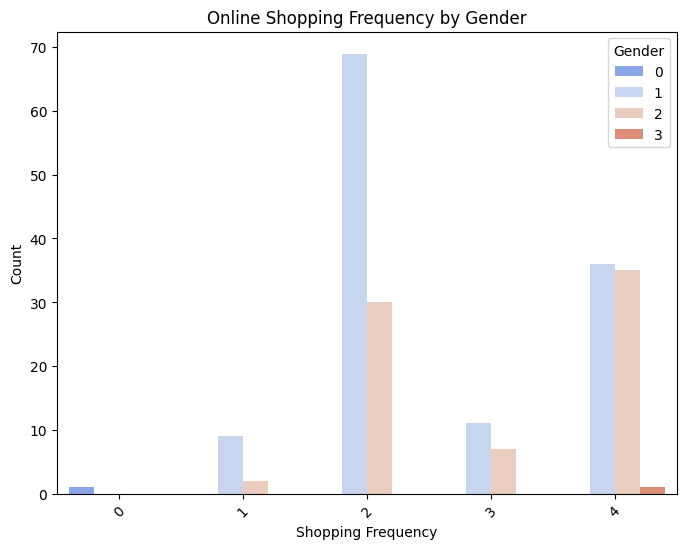

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Online_Shopping_Freq', hue='Gender', palette='coolwarm')
plt.title('Online Shopping Frequency by Gender')
plt.xlabel('Shopping Frequency')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show()

In [16]:
print(df[['Comfortable_Price_Range', 'Price_Sensitivity']].dtypes)

Comfortable_Price_Range    int64
Price_Sensitivity          int64
dtype: object


In [17]:
df['Price_Sensitivity'] = pd.to_numeric(df['Price_Sensitivity'], errors='coerce')
df['Comfortable_Price_Range'] = pd.to_numeric(df['Comfortable_Price_Range'], errors='coerce')

In [18]:
price_order = ['Low', 'Medium', 'High']  # Adjust as needed
df['Comfortable_Price_Range'] = pd.Categorical(df['Comfortable_Price_Range'], categories=price_order, ordered=True)

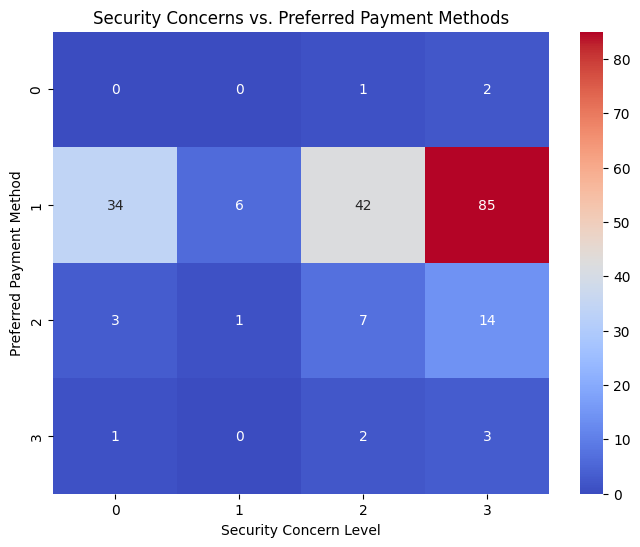

In [19]:
plt.figure(figsize=(8, 6))
heatmap_data = pd.crosstab(df['Preferred_Payment'], df['Security_Concern_Level'])
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='d')
plt.title('Security Concerns vs. Preferred Payment Methods')
plt.xlabel('Security Concern Level')
plt.ylabel('Preferred Payment Method')
plt.show()


In [20]:
print(df.isnull().sum())

Gender                          0
Online_Shopping_Freq            0
Online_Purchase_Proportion      0
Review_Check_Freq               0
Attraction_Factor               0
Retailer_Choice_Factors         0
Preferred_Payment               0
Local_vs_Intl_Retailers         0
Preferred_Marketplace           0
Security_Concern_Level          0
Promo_Participation             0
Price_Sensitivity               0
Comfortable_Price_Range       201
Frequent_Products               0
Major_Drawback                  0
Authenticity_Concern            0
Desired_Improvements            0
dtype: int64


In [21]:
for col in df.select_dtypes(include=['category']).columns:
    df[col] = df[col].cat.add_categories(["Comfortable_Price_Range"])

df.fillna("Comfortable_Price_Range", inplace=True)

<Figure size 1000x600 with 0 Axes>

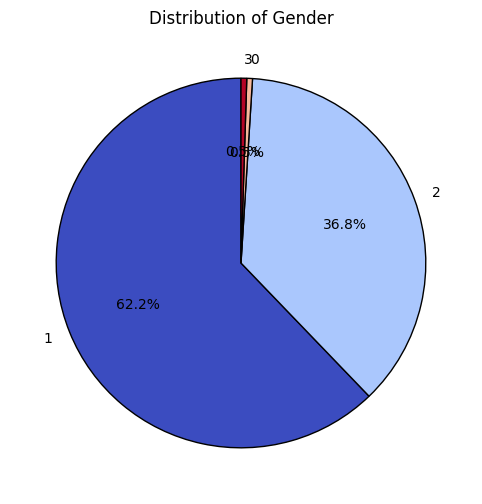

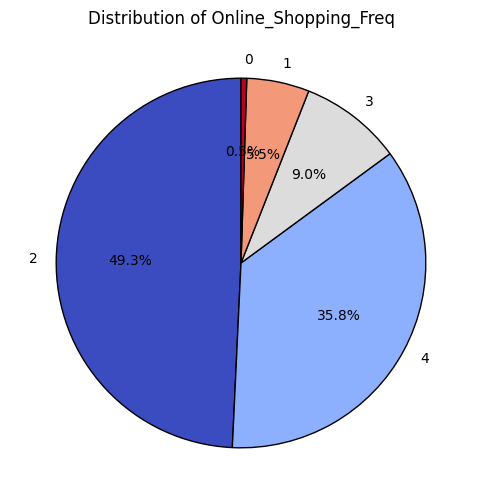

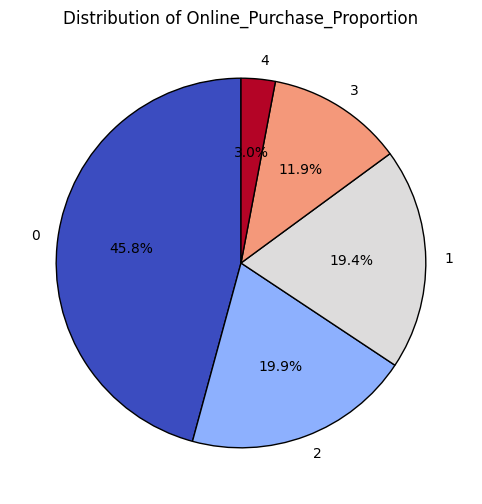

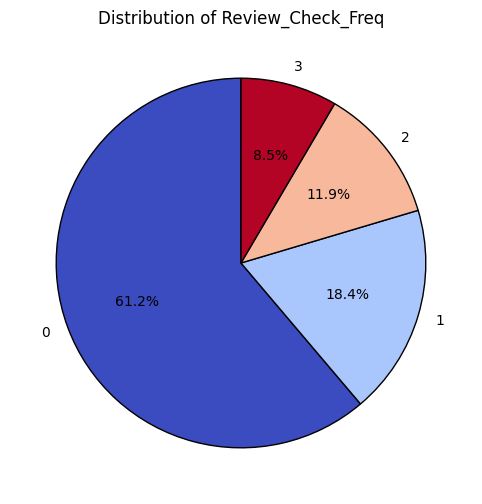

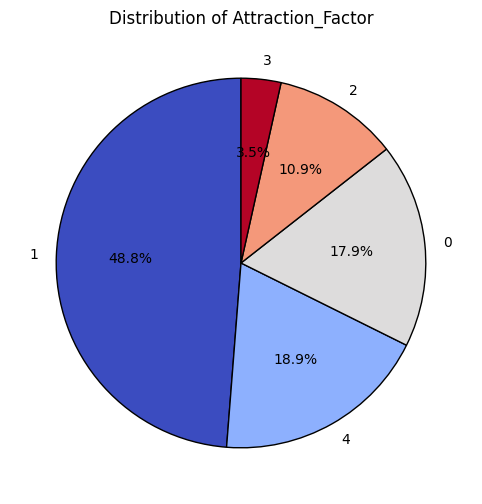

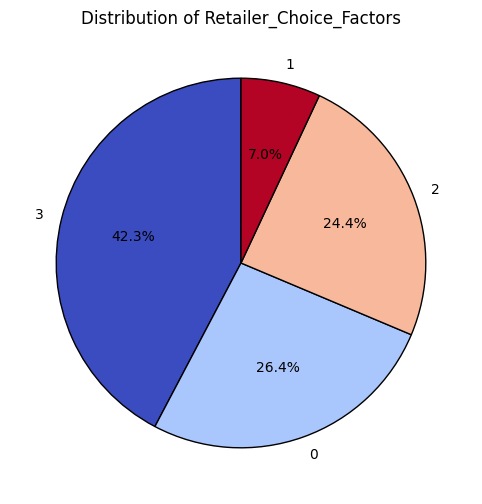

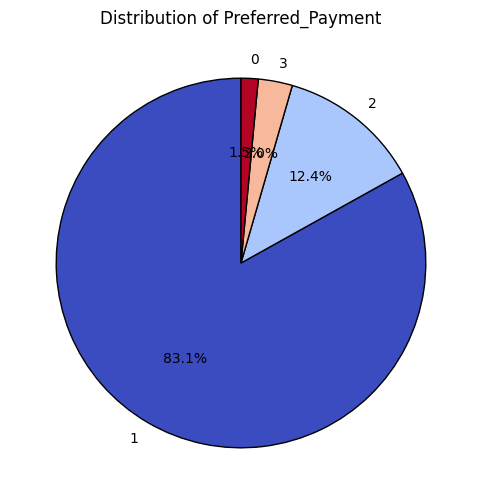

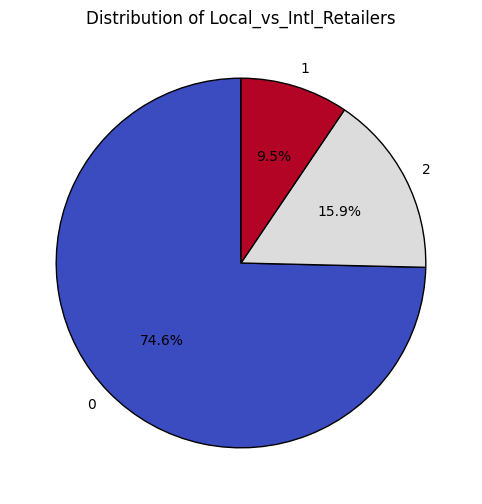

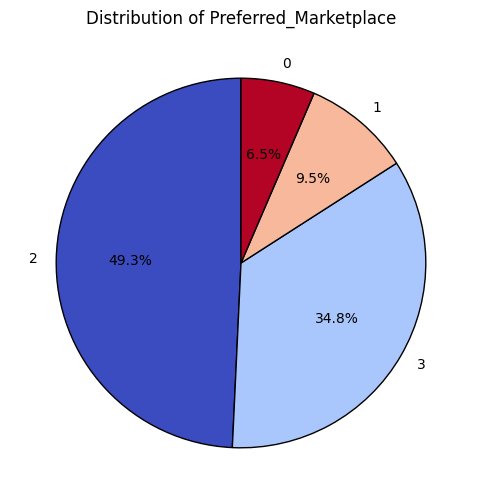

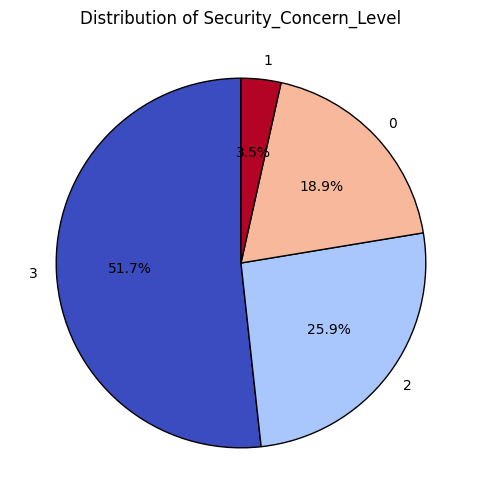

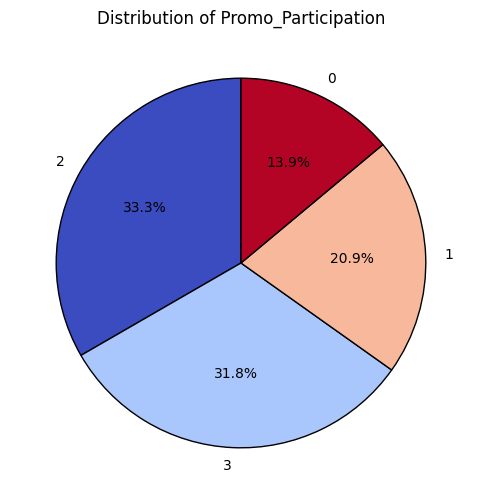

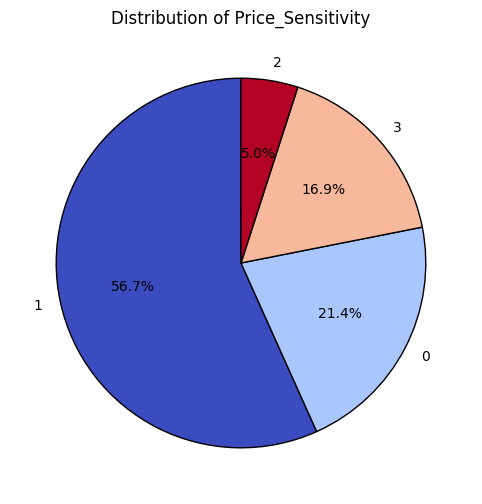

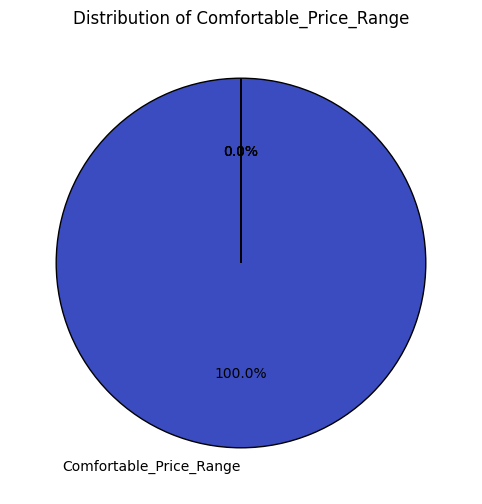

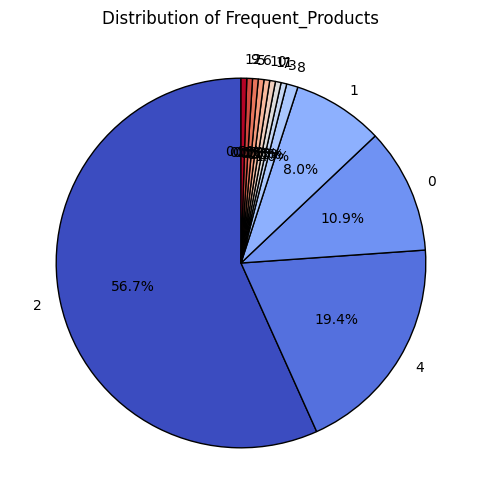

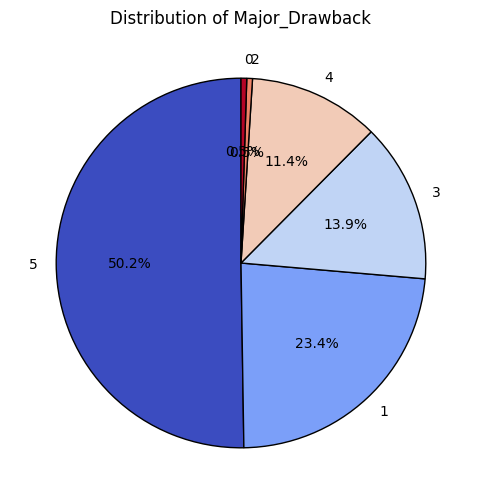

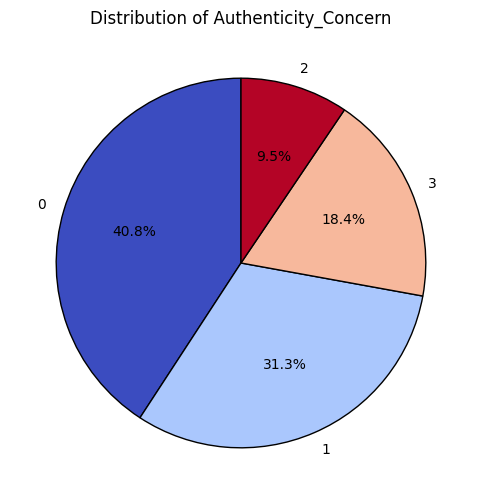

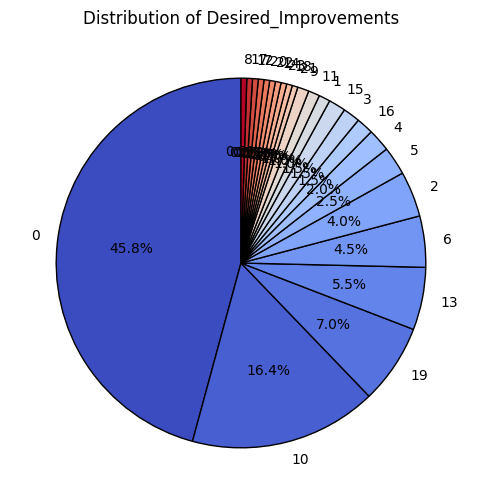

In [22]:
plt.figure(figsize=(10, 6))

for col in df.columns:
    plt.figure(figsize=(8, 6))
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='coolwarm', wedgeprops={'edgecolor': 'black'})
    plt.title(f'Distribution of {col}')
    plt.ylabel('')  # Hide y-label for better visualization
    plt.show()


In [23]:
# Check and handle missing values
if df.isnull().sum().sum() > 0:
    # For categorical data, filling with the mode is common
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])
            print(f'Filled missing values in {col} with mode.')
else:
    print('No missing values detected.')

# Create a copy of the dataframe for encoding
df_encoded = df.copy()

# Initialize label encoder
le = LabelEncoder()

# Encode all columns
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('Label encoding completed. Preview:')
display(df_encoded.head())

No missing values detected.
Label encoding completed. Preview:


,Gender,Online_Shopping_Freq,Online_Purchase_Proportion,Review_Check_Freq,Attraction_Factor,Retailer_Choice_Factors,Preferred_Payment,Local_vs_Intl_Retailers,Preferred_Marketplace,Security_Concern_Level,Promo_Participation,Price_Sensitivity,Comfortable_Price_Range,Frequent_Products,Major_Drawback,Authenticity_Concern,Desired_Improvements
0,2,4,0,0,1,0,2,0,2,3,2,1,0,2,5,1,10
1,1,4,0,0,0,3,1,0,3,0,3,3,0,2,1,1,10
2,1,2,2,0,1,0,1,0,2,2,1,1,0,2,5,3,3
3,2,2,2,0,1,3,1,2,0,2,3,1,0,2,1,1,0
4,1,4,0,1,1,0,1,0,1,3,3,1,0,1,5,2,6


In [24]:
df.isnull().sum()

Gender                        0
Online_Shopping_Freq          0
Online_Purchase_Proportion    0
Review_Check_Freq             0
Attraction_Factor             0
Retailer_Choice_Factors       0
Preferred_Payment             0
Local_vs_Intl_Retailers       0
Preferred_Marketplace         0
Security_Concern_Level        0
Promo_Participation           0
Price_Sensitivity             0
Comfortable_Price_Range       0
Frequent_Products             0
Major_Drawback                0
Authenticity_Concern          0
Desired_Improvements          0
dtype: int64

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

# Define target and features
target = 'Online_Shopping_Freq'
features = df_encoded.columns.tolist()
features.remove(target)

X = df_encoded[features]
y = df_encoded[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (for SVM & KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Train & Evaluate Models
results = {}

for name, model in models.items():
    if name in ["SVM", "Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.6585
Decision Tree: 0.4878
Random Forest: 0.5610
SVM: 0.6098
KNN: 0.5366
Gradient Boosting: 0.5854
XGBoost: 0.5122


Logistic Regression: 65.85%
Decision Tree: 48.78%
Random Forest: 56.10%
SVM: 60.98%
KNN: 53.66%
Gradient Boosting: 58.54%
XGBoost: 51.22%


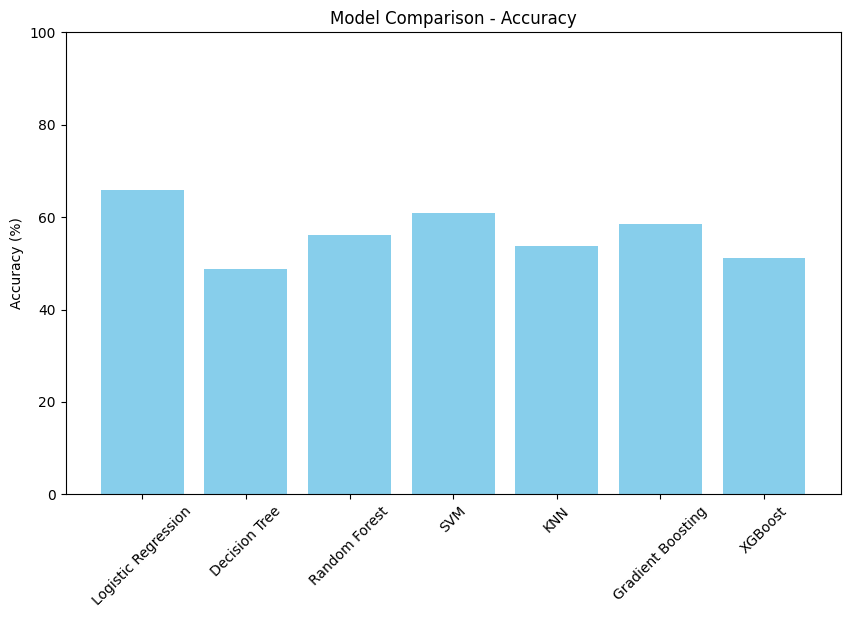

In [26]:
# Convert accuracy to percentage
results_percentage = {model: acc * 100 for model, acc in results.items()}

# Print results in percentage format
for model, acc in results_percentage.items():
    print(f"{model}: {acc:.2f}%")

# Visualization of model accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(results_percentage.keys(), results_percentage.values(), color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison - Accuracy")
plt.ylim(0, 100)  # Set y-axis limit to 0-100%
plt.show()


## Thank you...pls upvote..!!!!